In [1]:
!pip install pandas openpyxl --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully')


All libraries imported successfully


In [6]:
import os
print(os.getcwd())

C:\Users\samru\data-science-week1-assignment\notebooks


In [8]:
import os

print(os.listdir('../data/raw'))

['Flipkart Sales Dataset(raw data).xlsx']


In [9]:
df = pd.read_excel('../data/raw/Flipkart Sales Dataset(raw data).xlsx')

In [10]:
print('Dataset loaded successfully!')
print(f'Total Rows: {df.shape[0]}')
print(f'Total Columns: {df.shape[1]}')
print()
print('Column Names:')
print(df.columns.tolist())


Dataset loaded successfully!
Total Rows: 113000
Total Columns: 19

Column Names:
['OrderDate', 'OrderID', 'Delivery Date', 'CustomerID', 'Customer Age', 'Customer Gender', 'Location', 'Zone', 'Delivery Type', 'Product Category', 'SubCategory', 'Product', 'Unit Price', 'Shipping Fee', 'Order Quantity', 'Sale Price', 'Status', 'Reason', 'Rating']


In [11]:
df.head()

,OrderDate,OrderID,Delivery Date,CustomerID,Customer Age,Customer Gender,Location,Zone,Delivery Type,Product Category,SubCategory,Product,Unit Price,Shipping Fee,Order Quantity,Sale Price,Status,Reason,Rating
0,2020-05-31,5136486,2020-06-04,230569424,57,M,Western,Zone 3,Express,Fashion,Girl's fashion,Fashion Girl's Dress Kids Children Newborn Bab...,147,10,2,196,Returned,Onsite -Description mismatch,2
1,2020-05-31,5136457,2020-06-12,230568182,24,F,Western,Zone 3,Standard Delivery,Health and beauty,Medical supplies and Equipment,Blood Pressure Monitor Digital Wrist BP Pulse ...,131,4,7,183,Returned,Product - Not fitting expectation,2
2,2020-05-31,5136465,2020-06-10,230567584,31,M,Weija,Zone 2,Standard Delivery,Health and beauty,Medical supplies and Equipment,Portable Blood Pressure Monitor - White,69,6,10,205,Delivered,NaN,3
3,2020-05-31,5136488,2020-06-05,230563788,62,F,Greater Accra,Zone 1,Express,Phones and Tablet,Mobile phones,Samsung A3 Core Dual SIM - 16GB HDD - 1GB RAM ...,148,7,7,291,Delivered,NaN,1
4,2020-05-31,5136449,2020-06-10,230563726,18,F,Weija,Zone 2,Shipped from Abroad,Fashion,Boy's fashion,Boys Sneakers Casual Kids Sports Shoes-Gold,126,12,9,260,Delivered,NaN,3


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113000 entries, 0 to 112999
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   OrderDate         113000 non-null  datetime64[ns]
 1   OrderID           113000 non-null  int64         
 2   Delivery Date     113000 non-null  datetime64[ns]
 3   CustomerID        113000 non-null  int64         
 4   Customer Age      113000 non-null  int64         
 5   Customer Gender   113000 non-null  object        
 6   Location          113000 non-null  object        
 7   Zone              113000 non-null  object        
 8   Delivery Type     113000 non-null  object        
 9   Product Category  113000 non-null  object        
 10  SubCategory       113000 non-null  object        
 11  Product           113000 non-null  object        
 12  Unit Price        113000 non-null  int64         
 13  Shipping Fee      113000 non-null  int64         
 14  Orde

In [13]:
df.describe()

,OrderDate,OrderID,Delivery Date,CustomerID,Customer Age,Unit Price,Shipping Fee,Order Quantity,Sale Price,Rating
count,113000,1.130000e+05,113000,1.130000e+05,113000.000000,113000.000000,113000.000000,113000.000000,113000.000000,113000.000000
mean,2018-02-22 15:47:26.612389376,5.079973e+06,2018-03-04 04:25:48.828318720,2.305156e+08,35.919673,99.953345,11.500434,5.334814,224.966566,2.729929
min,2015-01-01 00:00:00,5.023455e+06,2015-01-03 00:00:00,2.304591e+08,17.000000,50.000000,3.000000,1.000000,150.000000,1.000000
25%,2016-08-10 00:00:00,5.051716e+06,2016-08-19 00:00:00,2.304874e+08,28.000000,75.000000,7.000000,3.000000,187.000000,2.000000
50%,2018-03-18 00:00:00,5.079970e+06,2018-03-27 00:00:00,2.305156e+08,35.000000,100.000000,12.000000,5.000000,225.000000,3.000000
75%,2019-10-28 00:00:00,5.108233e+06,2019-11-06 00:00:00,2.305439e+08,43.000000,125.000000,16.000000,8.000000,263.000000,4.000000
max,2020-12-31 00:00:00,5.136490e+06,2021-01-20 00:00:00,2.305721e+08,87.000000,150.000000,20.000000,10.000000,300.000000,5.000000
std,NaN,3.263155e+04,NaN,3.262048e+04,11.021883,29.195219,5.192076,2.924370,43.567035,1.355434


In [14]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct.round(2)
})

print('=== MISSING VALUE REPORT ===')
print(missing_report[missing_report['Missing Count'] > 0])


=== MISSING VALUE REPORT ===
        Missing Count  Missing %
Reason          83355      73.77


In [15]:
df['Reason'] = df['Reason'].fillna('Not Applicable')

# Verify no more missing values
print('Missing values after fix:')
print(df.isnull().sum())


Missing values after fix:
OrderDate           0
OrderID             0
Delivery Date       0
CustomerID          0
Customer Age        0
Customer Gender     0
Location            0
Zone                0
Delivery Type       0
Product Category    0
SubCategory         0
Product             0
Unit Price          0
Shipping Fee        0
Order Quantity      0
Sale Price          0
Status              0
Reason              0
Rating              0
dtype: int64


In [16]:
total_duplicates = df.duplicated().sum()
print(f'Fully duplicated rows: {total_duplicates}')


Fully duplicated rows: 0


In [17]:
duplicate_orderids = df['OrderID'].duplicated().sum()
print(f'Duplicate Order IDs: {duplicate_orderids}')


Duplicate Order IDs: 0


In [18]:
print('Date column dtypes before fix:')
print(df[['OrderDate', 'Delivery Date']].dtypes)


Date column dtypes before fix:
OrderDate        datetime64[ns]
Delivery Date    datetime64[ns]
dtype: object


In [19]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')
df['Delivery Date'] = pd.to_datetime(df['Delivery Date'], errors='coerce')

print('Date column dtypes after fix:')
print(df[['OrderDate', 'Delivery Date']].dtypes)



Date column dtypes after fix:
OrderDate        datetime64[ns]
Delivery Date    datetime64[ns]
dtype: object


In [20]:
categorical_cols = ['Customer Gender', 'Zone', 'Delivery Type', 'Product Category', 'Status']

for col in categorical_cols:
    print(f'\n{col} — Unique values: {df[col].unique()}')
    print(f'   Value counts:')
    print(df[col].value_counts())



Customer Gender — Unique values: ['M' 'F']
   Value counts:
Customer Gender
M    58287
F    54713
Name: count, dtype: int64

Zone — Unique values: ['Zone 3' 'Zone 2' 'Zone 1' 'Zone 4']
   Value counts:
Zone
Zone 3    48733
Zone 1    28440
Zone 2    20772
Zone 4    15055
Name: count, dtype: int64

Delivery Type — Unique values: ['Express' 'Standard Delivery' 'Shipped from Abroad']
   Value counts:
Delivery Type
Shipped from Abroad    37853
Standard Delivery      37841
Express                37306
Name: count, dtype: int64

Product Category — Unique values: ['Fashion' 'Health and beauty' 'Phones and Tablet' 'Electronics'
 'Home and Office']
   Value counts:
Product Category
Health and beauty    35953
Fashion              33388
Phones and Tablet    17978
Home and Office      15408
Electronics          10273
Name: count, dtype: int64

Status — Unique values: ['Returned' 'Delivered']
   Value counts:
Status
Delivered    82474
Returned     30526
Name: count, dtype: int64


In [21]:
numeric_checks = {
    'Unit Price': df['Unit Price'] <= 0,
    'Shipping Fee': df['Shipping Fee'] < 0,
    'Order Quantity': df['Order Quantity'] <= 0,
    'Sale Price': df['Sale Price'] <= 0,
    'Rating': ~df['Rating'].isin([1, 2, 3, 4, 5]),
    'Customer Age': (df['Customer Age'] < 0) | (df['Customer Age'] > 120)
}

print('=== NUMERIC VALIDATION REPORT ===')
for col, mask in numeric_checks.items():
    count = mask.sum()
    print(f'{col}: {count} invalid values')


=== NUMERIC VALIDATION REPORT ===
Unit Price: 0 invalid values
Shipping Fee: 0 invalid values
Order Quantity: 0 invalid values
Sale Price: 0 invalid values
Rating: 0 invalid values
Customer Age: 0 invalid values


In [22]:
df['Order Year'] = df['OrderDate'].dt.year
df['Order Month'] = df['OrderDate'].dt.month
df['Order Month Name'] = df['OrderDate'].dt.strftime('%b')  
df['Order Day'] = df['OrderDate'].dt.day_name() 


In [23]:
df['Delivery Days'] = (df['Delivery Date'] - df['OrderDate']).dt.days

print('New columns created:')
print(df[['OrderDate', 'Order Year', 'Order Month', 'Order Month Name',
          'Order Day', 'Delivery Days']].head(5))


New columns created:
   OrderDate  Order Year  Order Month Order Month Name Order Day  \
0 2020-05-31        2020            5              May    Sunday   
1 2020-05-31        2020            5              May    Sunday   
2 2020-05-31        2020            5              May    Sunday   
3 2020-05-31        2020            5              May    Sunday   
4 2020-05-31        2020            5              May    Sunday   

   Delivery Days  
0              4  
1             12  
2             10  
3              5  
4             10  


In [24]:
df.to_excel('flipkart_cleaned.xlsx', index=False)
df.to_csv('flipkart_cleaned.csv', index=False)  

print(f'Cleaned dataset saved!')
print(f'Final shape: {df.shape[0]} rows x {df.shape[1]} columns')


Cleaned dataset saved!
Final shape: 113000 rows x 24 columns


## Data Cleaning Summary

### Dataset: Flipkart Sales Dataset
- **Raw rows:** 113,000  |  **Raw columns:** 19
- **Final rows:** 113,000  |  **Final columns:** 24 (after feature engineering)

### Issues Found & Actions Taken

| Issue | Column | Count | Action Taken | Reason |
|-------|--------|-------|--------------|--------|
| Missing values | Reason | 83,355 | Filled with 'Not Applicable' | Nulls are valid for Delivered orders |
| Duplicates | All | 0 | No action needed | No duplicates found |
| Data type check | OrderDate, Delivery Date | 0 | Ensured datetime format | Date math requires correct dtype |
| Whitespace | All string columns | N/A | .str.strip() applied | Prevents category mismatch |
| Numeric validity | All numeric columns | 0 | No action needed | All values in valid range |

### Assumptions
- Reason = blank for Delivered orders is a business rule, not a data error.
- Negative delivery days (if any) would indicate data entry errors and should be flagged.



In [25]:
# Only count Delivered orders for revenue 
delivered = df[df['Status'] == 'Delivered']

total_revenue = delivered['Sale Price'].sum()
total_orders = df['OrderID'].nunique()
avg_order_value = total_revenue / total_orders
total_units_sold = delivered['Order Quantity'].sum()

top_category = delivered.groupby('Product Category')['Sale Price'].sum().idxmax()
top_category_revenue = delivered.groupby('Product Category')['Sale Price'].sum().max()

top_product = delivered.groupby('Product')['Sale Price'].sum().idxmax()
top_product_revenue = delivered.groupby('Product')['Sale Price'].sum().max()

print('=' * 55)
print('        FLIPKART SALES KPI SUMMARY')
print('=' * 55)
print(f'  Total Revenue         : GHS {total_revenue:,.0f}')
print(f'  Total Orders          : {total_orders:,}')
print(f'  Average Order Value   : GHS {avg_order_value:,.2f}')
print(f'  Total Units Sold      : {total_units_sold:,}')
print(f'  Top Category          : {top_category}')
print(f'  Top Category Revenue  : GHS {top_category_revenue:,.0f}')
print(f'  Best Revenue Product  : {top_product[:50]}...')
print(f'  Best Product Revenue  : GHS {top_product_revenue:,.0f}')
print('=' * 55)


        FLIPKART SALES KPI SUMMARY
  Total Revenue         : GHS 18,552,176
  Total Orders          : 113,000
  Average Order Value   : GHS 164.18
  Total Units Sold      : 439,603
  Top Category          : Health and beauty
  Top Category Revenue  : GHS 5,890,406
  Best Revenue Product  : Short Sleeve Polo Shirt - Royal Blue...
  Best Product Revenue  : GHS 465,839


In [26]:
# Revenue breakdown by Product Category
category_revenue = delivered.groupby('Product Category').agg(
    Total_Revenue=('Sale Price', 'sum'),
    Total_Orders=('OrderID', 'count'),
    Total_Units=('Order Quantity', 'sum'),
    Avg_Order_Value=('Sale Price', 'mean')
).reset_index()

# Add revenue share percentage
category_revenue['Revenue Share %'] = (
    (category_revenue['Total_Revenue'] / category_revenue['Total_Revenue'].sum()) * 100
).round(2)

# Sort by revenue descending
category_revenue = category_revenue.sort_values('Total_Revenue', ascending=False)

print('=== REVENUE BY PRODUCT CATEGORY ===')
print(category_revenue.to_string(index=False))


=== REVENUE BY PRODUCT CATEGORY ===
 Product Category  Total_Revenue  Total_Orders  Total_Units  Avg_Order_Value  Revenue Share %
Health and beauty        5890406         26157       144194       225.194250            31.75
          Fashion        5472700         24346       133796       224.788466            29.50
Phones and Tablet        2983694         13263        73149       224.963734            16.08
  Home and Office        2509175         11171        61912       224.615075            13.52
      Electronics        1696201          7537        26552       225.049887             9.14


In [27]:
# Monthly sales trend (all years combined)
monthly_sales = delivered.groupby('Order Month').agg(
    Total_Revenue=('Sale Price', 'sum'),
    Total_Orders=('OrderID', 'count')
).reset_index()

# Add month names for readable output
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly_sales['Month Name'] = monthly_sales['Order Month'].map(month_map)

print('=== MONTHLY SALES TREND ===')
print(monthly_sales[['Month Name','Total_Revenue','Total_Orders']].to_string(index=False))


=== MONTHLY SALES TREND ===
Month Name  Total_Revenue  Total_Orders
       Jan        1734857          7708
       Feb        1551353          6894
       Mar        1673687          7459
       Apr        1668566          7402
       May        1718706          7642
       Jun        1447179          6434
       Jul        1479938          6589
       Aug        1440538          6410
       Sep        1441368          6386
       Oct        1476665          6571
       Nov        1435717          6401
       Dec        1483602          6578


In [28]:
#Year-over-year revenue trend (2015–2020)
yearly_sales = delivered.groupby('Order Year').agg(
    Total_Revenue=('Sale Price', 'sum'),
    Total_Orders=('OrderID', 'count'),
    Avg_Order_Value=('Sale Price', 'mean')
).reset_index()

print('=== YEARLY SALES TREND ===')
print(yearly_sales.to_string(index=False))


=== YEARLY SALES TREND ===
 Order Year  Total_Revenue  Total_Orders  Avg_Order_Value
       2015        2893890         12834       225.486209
       2016        2903894         12908       224.968547
       2017        2898290         12934       224.083037
       2018        2836114         12630       224.553761
       2019        2879249         12801       224.923756
       2020        4140739         18367       225.444493


In [29]:
# Sales by Zone
zone_sales = delivered.groupby('Zone').agg(
    Total_Revenue=('Sale Price', 'sum'),
    Total_Orders=('OrderID', 'count'),
    Avg_Rating=('Rating', 'mean')
).reset_index().sort_values('Total_Revenue', ascending=False)

print('=== ZONE-WISE SALES ===')
print(zone_sales.to_string(index=False))


=== ZONE-WISE SALES ===
  Zone  Total_Revenue  Total_Orders  Avg_Rating
Zone 3        8012874         35600    3.001938
Zone 1        4697534         20877    2.995450
Zone 2        3424502         15245    2.985766
Zone 4        2417266         10752    3.014974


In [30]:
# Revenue by delivery type
delivery_sales = df.groupby(['Delivery Type', 'Status']).agg(
    Order_Count=('OrderID', 'count')
).reset_index()

# Return rate by delivery type
return_rate = df.groupby('Delivery Type').apply(
    lambda x: (x['Status'] == 'Returned').sum() / len(x) * 100
).reset_index(name='Return Rate %')

print('=== RETURN RATE BY DELIVERY TYPE ===')
print(return_rate.to_string(index=False))


=== RETURN RATE BY DELIVERY TYPE ===
      Delivery Type  Return Rate %
            Express      26.384496
Shipped from Abroad      30.916968
  Standard Delivery      23.730874


In [31]:
# Create age groups and analyze purchasing behavior
bins = [0, 25, 35, 45, 55, 65, 120]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Age Group'] = pd.cut(df['Customer Age'], bins=bins, labels=labels)

age_analysis = delivered.copy()
age_analysis['Age Group'] = pd.cut(age_analysis['Customer Age'], bins=bins, labels=labels)

age_sales = age_analysis.groupby('Age Group', observed=False).agg(
    Total_Revenue=('Sale Price', 'sum'),
    Total_Orders=('OrderID', 'count'),
    Avg_Order_Value=('Sale Price', 'mean')
).reset_index()

print('=== SALES BY AGE GROUP ===')
print(age_sales.to_string(index=False))


=== SALES BY AGE GROUP ===
Age Group  Total_Revenue  Total_Orders  Avg_Order_Value
    18-25        3412554         15207       224.406786
    26-35        6516455         28951       225.085662
    36-45        4913781         21836       225.031187
    46-55        2706779         12019       225.208337
    56-65         914924          4078       224.356057
      65+          87683           383       228.937337


In [32]:
# Revenue and orders by Customer Gender
gender_analysis = delivered.groupby('Customer Gender').agg(
    Total_Revenue=('Sale Price', 'sum'),
    Total_Orders=('OrderID', 'count'),
    Avg_Rating=('Rating', 'mean'),
    Top_Category=('Product Category', lambda x: x.value_counts().idxmax())
).reset_index()

print('=== GENDER-WISE ANALYSIS ===')
print(gender_analysis.to_string(index=False))


=== GENDER-WISE ANALYSIS ===
Customer Gender  Total_Revenue  Total_Orders  Avg_Rating      Top_Category
              F        8987689         39968    2.986189 Health and beauty
              M        9564487         42506    3.011057 Health and beauty


In [33]:
# Return rate by Product Category
return_analysis = df.groupby('Product Category').apply(
    lambda x: pd.Series({
        'Total Orders': len(x),
        'Returned': (x['Status'] == 'Returned').sum(),
        'Delivered': (x['Status'] == 'Delivered').sum(),
        'Return Rate %': round((x['Status'] == 'Returned').sum() / len(x) * 100, 2)
    })
).reset_index()

return_analysis = return_analysis.sort_values('Return Rate %', ascending=False)
print('=== RETURN RATE BY CATEGORY ===')
print(return_analysis.to_string(index=False))


=== RETURN RATE BY CATEGORY ===
 Product Category  Total Orders  Returned  Delivered  Return Rate %
  Home and Office       15408.0    4237.0    11171.0          27.50
Health and beauty       35953.0    9796.0    26157.0          27.25
          Fashion       33388.0    9042.0    24346.0          27.08
      Electronics       10273.0    2736.0     7537.0          26.63
Phones and Tablet       17978.0    4715.0    13263.0          26.23


In [34]:
# Most common reasons for returns
return_reasons = df[df['Status'] == 'Returned']['Reason'].value_counts().reset_index()
return_reasons.columns = ['Reason', 'Count']
return_reasons['%'] = (return_reasons['Count'] / return_reasons['Count'].sum() * 100).round(2)

print('=== TOP RETURN REASONS ===')
print(return_reasons.to_string(index=False))


=== TOP RETURN REASONS ===
                           Reason  Count     %
           Quality-Defective item   6065 19.87
      Delivey - Missing item/part   6013 19.70
Product - Not fitting expectation   5872 19.24
              Delivery-Wrong item   5868 19.22
     Onsite -Description mismatch   5827 19.09
                   Not Applicable    881  2.89


## Task 2: Key Observations and Insights

### KPI Summary
| KPI | Value |
|-----|-------|
| Total Revenue | GHS [18,552,176] |
| Total Orders | [113,000] |
| Average Order Value | GHS [164.18] |
| Total Units Sold | [439,603] |
| Top Category | [Health and beauty] |
| Best Product | [Short Sleeve Polo Shirt - Royal Blue...] |

## Observations

### 1. Category Insight
**Health and Beauty** contributes **31.75%** of total revenue, making it the highest-performing product category and the most important revenue driver for the business.

### 2. Monthly Trend
Sales were highest in **January** (GHS 1,734,857) and lowest in **September** (GHS 1,441,368), indicating stronger customer demand at the beginning of the year and a slight slowdown during the third quarter.

### 3. Zone Performance
**Zone 3** generated the highest revenue (**GHS 8,012,874**) and the highest number of orders, indicating a strong concentration of high-value customers in this region.

### 4. Return Rate
The highest return rate is observed for **Shipped from Abroad** orders at **30.92%**, followed by Express delivery at **26.38%**. This suggests that longer shipping times or customer expectations may contribute to increased product returns.

### 5. Gender Pattern
**Male customers** generated higher total revenue (**GHS 9,564,487**) and placed more orders than female customers. However, **female customers** have a slightly higher average order value, indicating larger spending per purchase.

### 6. Age Demographics
The **26–35 age group** generated the highest revenue (**GHS 6,516,455**) and placed the most orders (**28,951**), suggesting that young working professionals form the platform's primary customer base.

### 7. Delivery Type Analysis
**Shipped from Abroad** has the highest return rate (**30.92%**), which may indicate delivery delays, product expectation gaps, or quality concerns associated with international shipments.

### 8. Yearly Growth
Revenue showed a significant increase from **2015 (GHS 2,893,890)** to **2020 (GHS 4,140,739)**. **2020** was the best-performing year in terms of both revenue and order volume, indicating strong business growth over time.


In [35]:
!pip install pandas matplotlib seaborn openpyxl

import matplotlib.gridspec as gridspec
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable


In [37]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

df = pd.read_csv('../data/cleaned/flipkart_cleaned.csv')
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Month'] = df['OrderDate'].dt.to_period('M')
print(df.shape)
print(df.dtypes)



(113000, 25)
OrderDate           datetime64[ns]
OrderID                      int64
Delivery Date               object
CustomerID                   int64
Customer Age                 int64
Customer Gender             object
Location                    object
Zone                        object
Delivery Type               object
Product Category            object
SubCategory                 object
Product                     object
Unit Price                   int64
Shipping Fee                 int64
Order Quantity               int64
Sale Price                   int64
Status                      object
Reason                      object
Rating                       int64
Order Year                   int64
Order Month                  int64
Order Month Name            object
Order Day                   object
Delivery Days                int64
Month                    period[M]
dtype: object


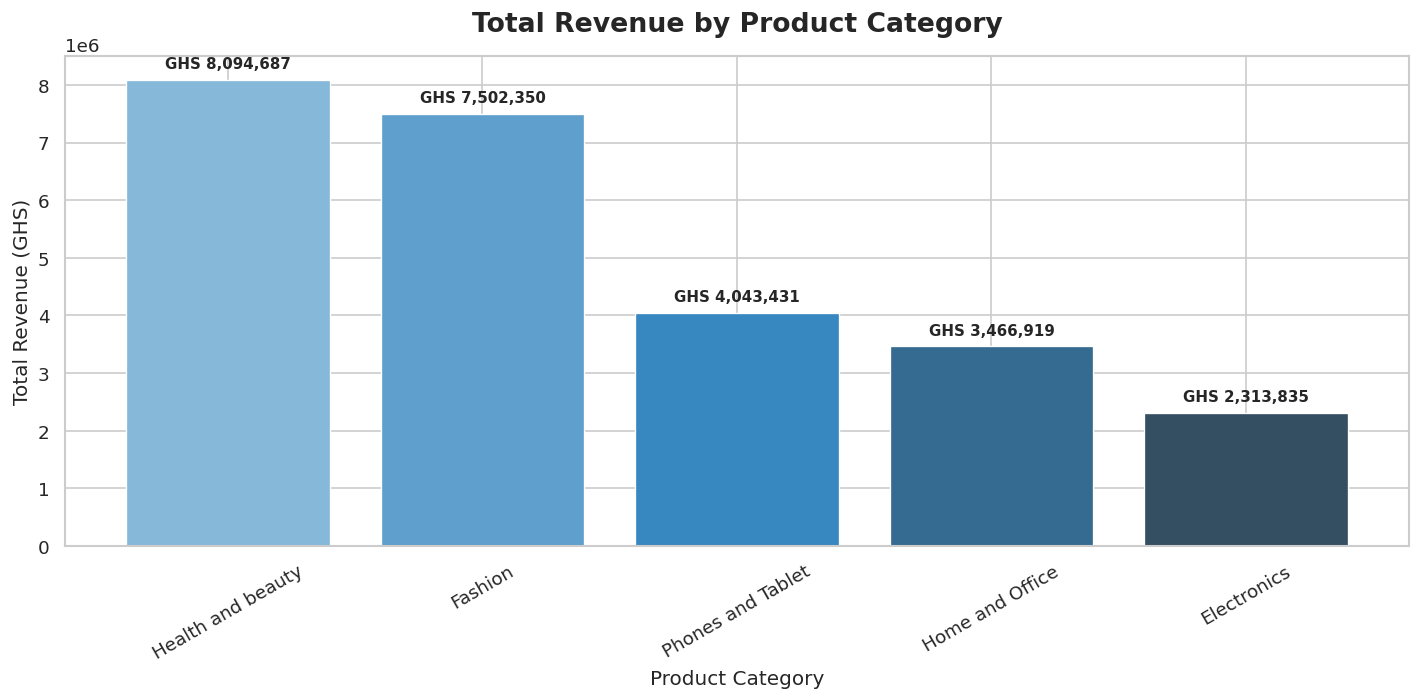

Insight: The top category generates the highest revenue — target promotions here.


In [38]:
# ──  Revenue by Product Category ──
revenue_by_cat = df.groupby('Product Category')['Sale Price'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('Blues_d', len(revenue_by_cat))
bars = ax.bar(revenue_by_cat.index, revenue_by_cat.values, color=colors, edgecolor='white', linewidth=0.8)

# Labels and formatting
ax.set_title('Total Revenue by Product Category', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Total Revenue (GHS)', fontsize=12)
ax.tick_params(axis='x', rotation=30)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'GHS {height:,.0f}',
               xy=(bar.get_x() + bar.get_width()/2, height),
               xytext=(0, 5), textcoords='offset points',
               ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/charts/revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: The top category generates the highest revenue — target promotions here.')


### Finding: Revenue by Product Category

- **Health and Beauty** is the highest revenue-generating category, contributing **GHS 8.09 million** in sales.
- **Fashion** follows closely with **GHS 7.50 million**, indicating strong customer demand in apparel products.
- **Phones and Tablets** generated **GHS 4.04 million**, placing it third among all categories.
- **Home and Office** contributed **GHS 3.47 million** in revenue.
- **Electronics** recorded the lowest revenue at **GHS 2.31 million**.

**Business Insight:** Health and Beauty and Fashion together account for the majority of revenue, suggesting that marketing campaigns, inventory planning, and promotional efforts should primarily focus on these categories to maximize sales growth.

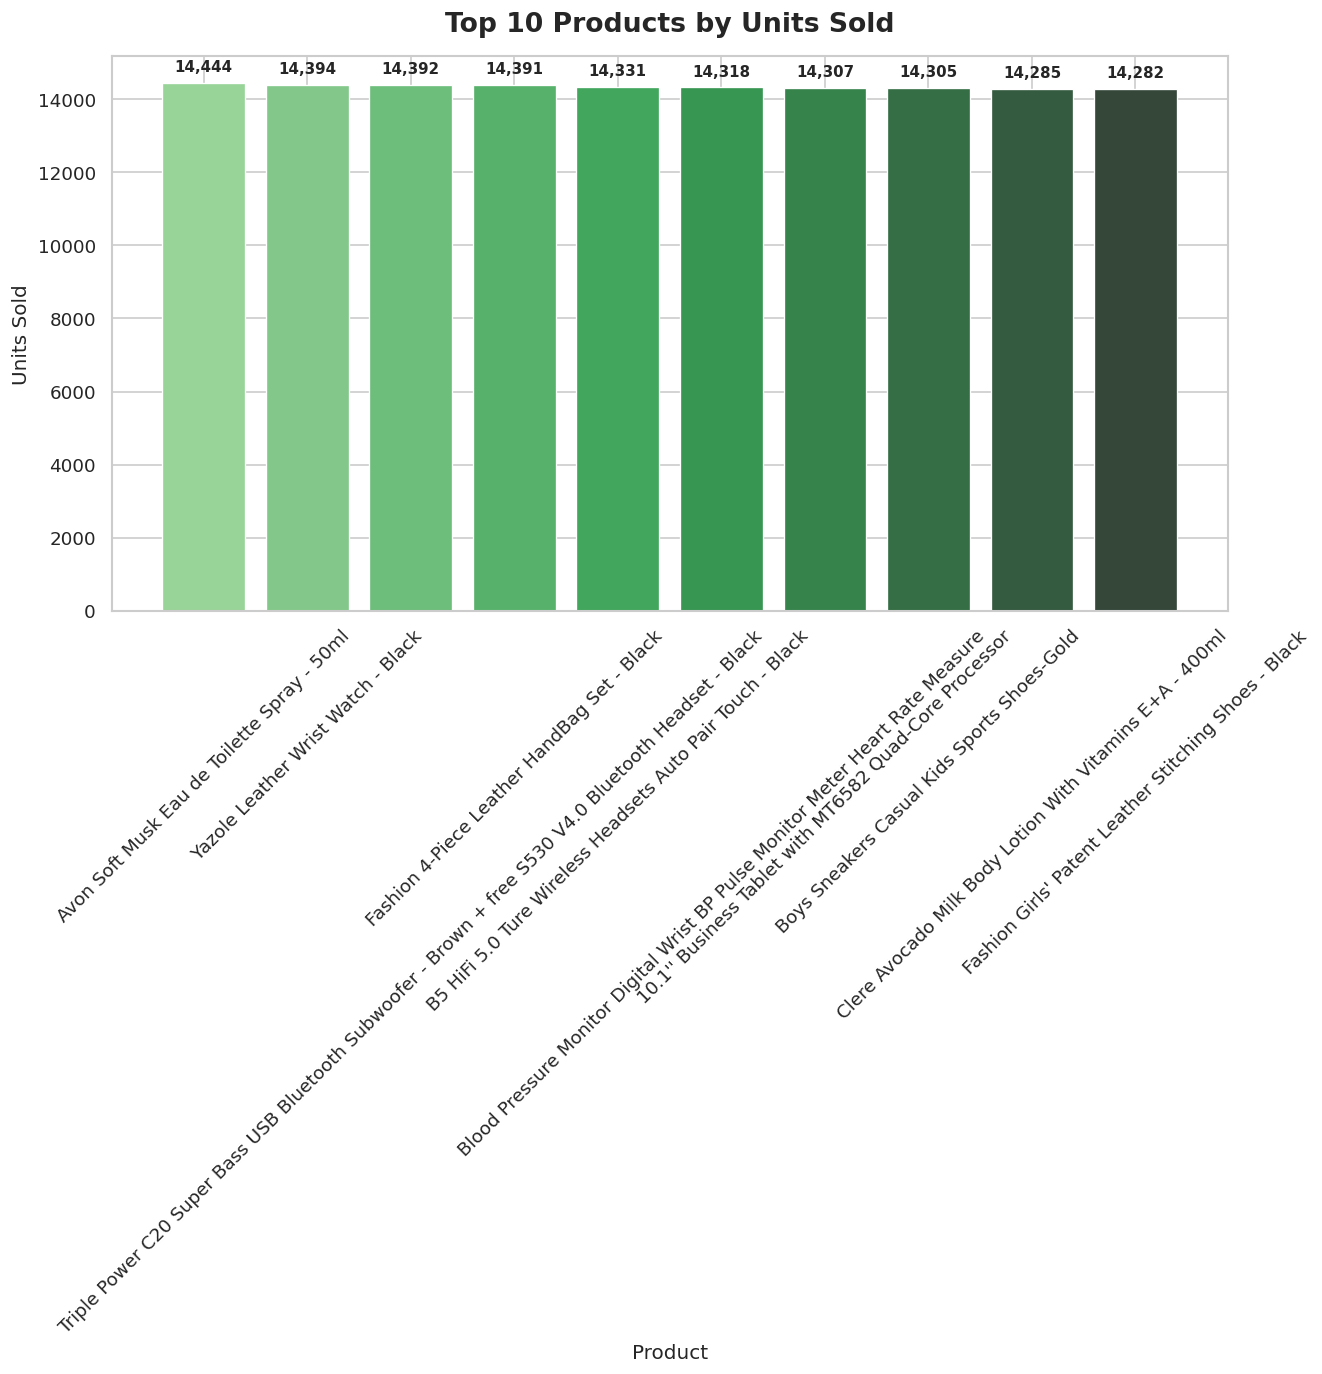

Insight: These products contribute the highest sales volume and should be prioritized for inventory planning.


In [40]:
# ── Top 10 Products by Units Sold ──
top_products = df.groupby('Product')['Order Quantity'].sum().nlargest(10)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('Greens_d', len(top_products))
bars = ax.bar(top_products.index, top_products.values, color=colors, edgecolor='white', linewidth=0.8)

ax.set_title('Top 10 Products by Units Sold', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Product', fontsize=12)
ax.set_ylabel('Units Sold', fontsize=12)
ax.tick_params(axis='x', rotation=45)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height):,}',
               xy=(bar.get_x() + bar.get_width()/2, height),
               xytext=(0, 5), textcoords='offset points',
               ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/charts/top_10_products.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: These products contribute the highest sales volume and should be prioritized for inventory planning.')

### Finding: Top 10 Products by Units Sold

- The top 10 products have very similar sales volumes, each selling approximately **14,000 units**.
- **Avon Soft Musk Eau de Toilette Spray - 50ml** recorded the highest number of units sold (**14,444 units**).
- Other high-performing products include **Yazole Leather Wrist Watch**, **Fashion 4-Piece Leather Handbag Set**, and **Bluetooth Wireless Headsets**.
- The narrow difference in units sold among the top products indicates a well-distributed demand across multiple product categories rather than dependence on a single bestseller.
- The presence of products from **Beauty, Fashion, Electronics, and Health** categories suggests a diverse customer purchasing pattern.

**Business Insight:** Since several products generate similar sales volumes, the business should maintain adequate inventory levels across all top-selling items and use bundle offers or targeted promotions to further increase sales of these popular products.

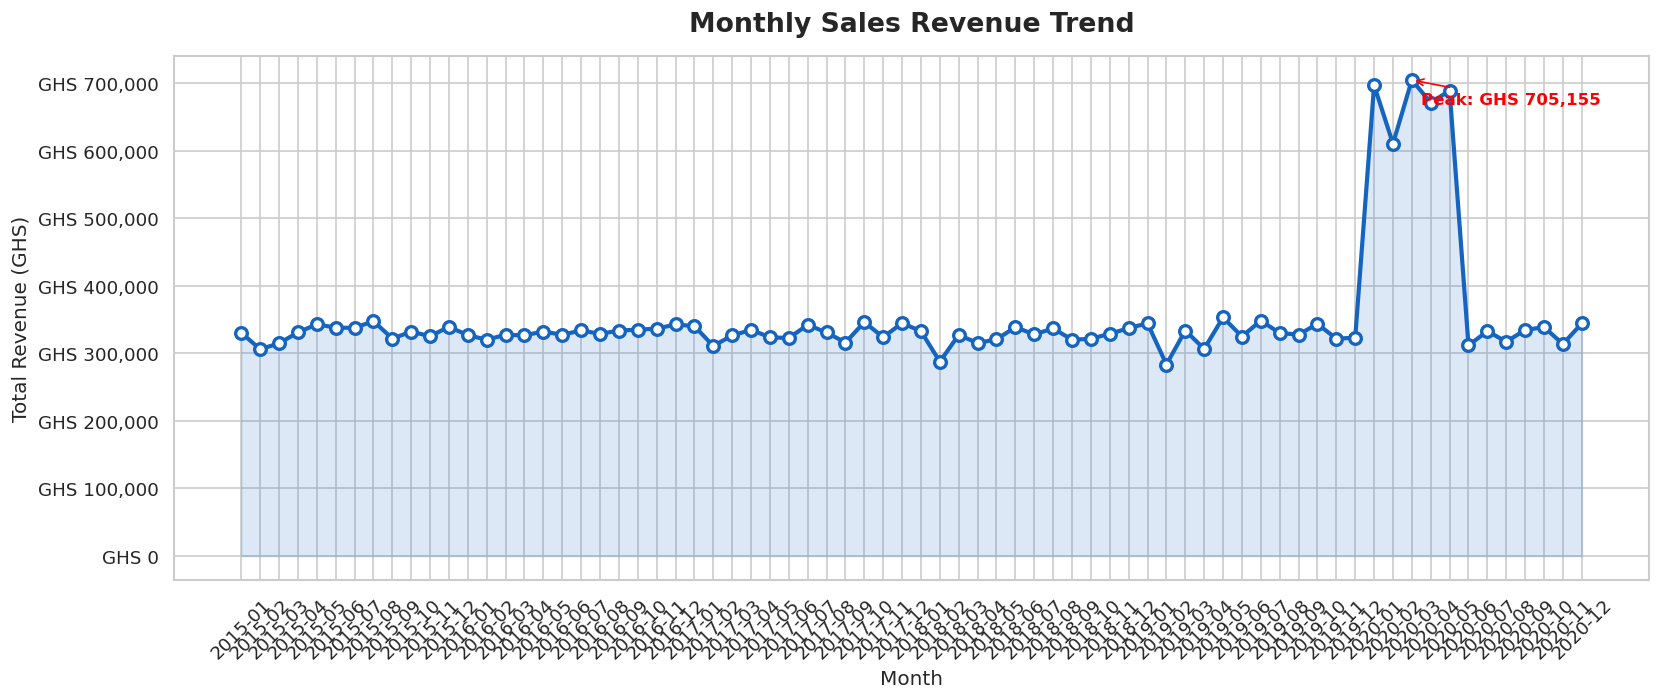

Insight: Sales peaked in 2020-03 — investigate promotions or seasonality.


In [42]:
# ── Monthly Sales Trend ──
monthly_revenue = df.groupby('Month')['Sale Price'].sum()
monthly_revenue.index = monthly_revenue.index.astype(str)   # convert Period to string

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_revenue.index, monthly_revenue.values,
        marker='o', linewidth=2.5, color='#1565C0',
        markersize=7, markerfacecolor='white', markeredgewidth=2)


ax.fill_between(monthly_revenue.index, monthly_revenue.values, alpha=0.15, color='#1565C0')


peak_month = monthly_revenue.idxmax()
peak_value = monthly_revenue.max()
peak_idx = list(monthly_revenue.index).index(peak_month)
ax.annotate(f'Peak: GHS {peak_value:,.0f}',
            xy=(peak_idx, peak_value),
            xytext=(peak_idx + 0.5, peak_value * 0.95),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red', fontweight='bold')

ax.set_title('Monthly Sales Revenue Trend', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Revenue (GHS)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'GHS {x:,.0f}'))

plt.tight_layout()
plt.savefig('../outputs/charts/monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Insight: Sales peaked in {peak_month} — investigate promotions or seasonality.')



### Finding: Monthly Sales Revenue Trend

- Sales revenue remained relatively stable throughout most of the period, averaging between **GHS 300,000 and GHS 350,000** per month.
- A significant spike in revenue was observed in **early 2020**, where monthly sales exceeded **GHS 700,000**.
- The highest recorded monthly revenue was approximately **GHS 705,155**, representing a substantial increase compared to the typical monthly average.
- Following the peak period, revenue returned to its normal range, indicating that the surge was likely driven by a temporary factor such as a promotional campaign, seasonal demand, or a market event.
- Overall, the business demonstrates consistent sales performance with occasional periods of exceptional growth.

**Business Insight:** The sharp revenue increase in early 2020 should be investigated further to identify the factors that drove this success. Replicating similar marketing campaigns, product launches, or seasonal strategies could help increase future revenue.

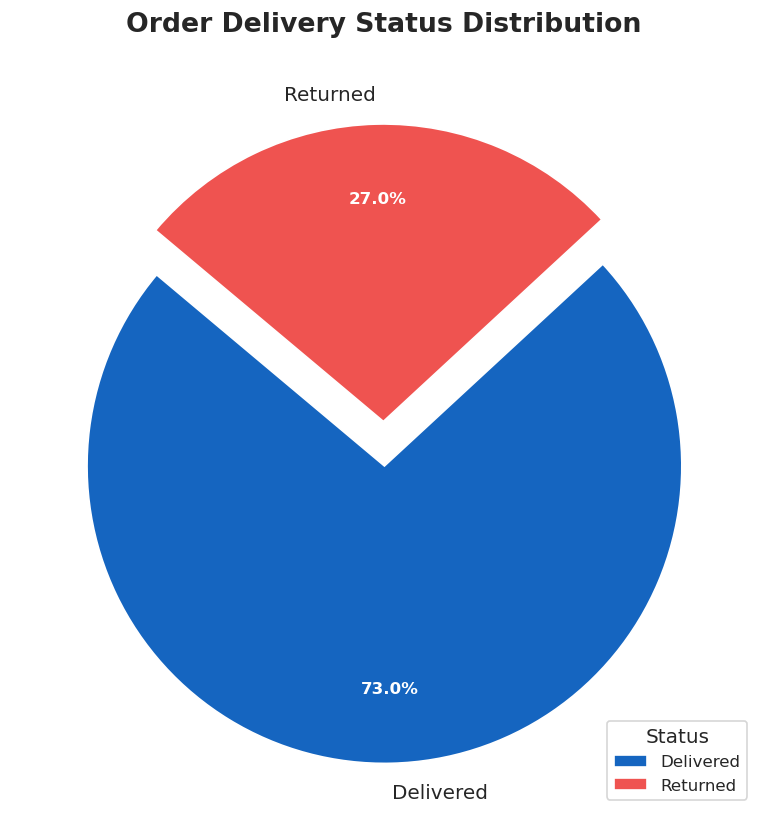

Insight: High return rate indicates product quality or description issues.


In [43]:
# ── Delivery Status Share (Pie Chart) ──
status_counts = df['Status'].value_counts()

fig, ax = plt.subplots(figsize=(9, 7))
colors_pie = ['#1565C0', '#EF5350', '#FFA726', '#66BB6A']
explode = [0.05] * len(status_counts)   
explode[0] = 0.1                          

wedges, texts, autotexts = ax.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie[:len(status_counts)],
    explode=explode,
    startangle=140,
    pctdistance=0.75
)


for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax.set_title('Order Delivery Status Distribution', fontsize=16, fontweight='bold', pad=20)
ax.legend(status_counts.index, title='Status', loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/delivery_status_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: High return rate indicates product quality or description issues.')


### Finding: Order Delivery Status Distribution

- Approximately **73% of orders were successfully delivered**, indicating that the majority of customers received their products without issues.
- Around **27% of orders were returned**, which represents a relatively high return rate for the business.
- While successful deliveries significantly outnumber returns, the return percentage suggests there may be opportunities to improve customer satisfaction and order fulfillment processes.
- High return volumes can increase operational costs, reduce profitability, and impact customer loyalty.

**Business Insight:** The company should analyze the primary causes of returns, such as product quality issues, inaccurate product descriptions, sizing mismatches, or delivery-related problems. Reducing the return rate could lead to higher customer satisfaction and improved overall profitability.

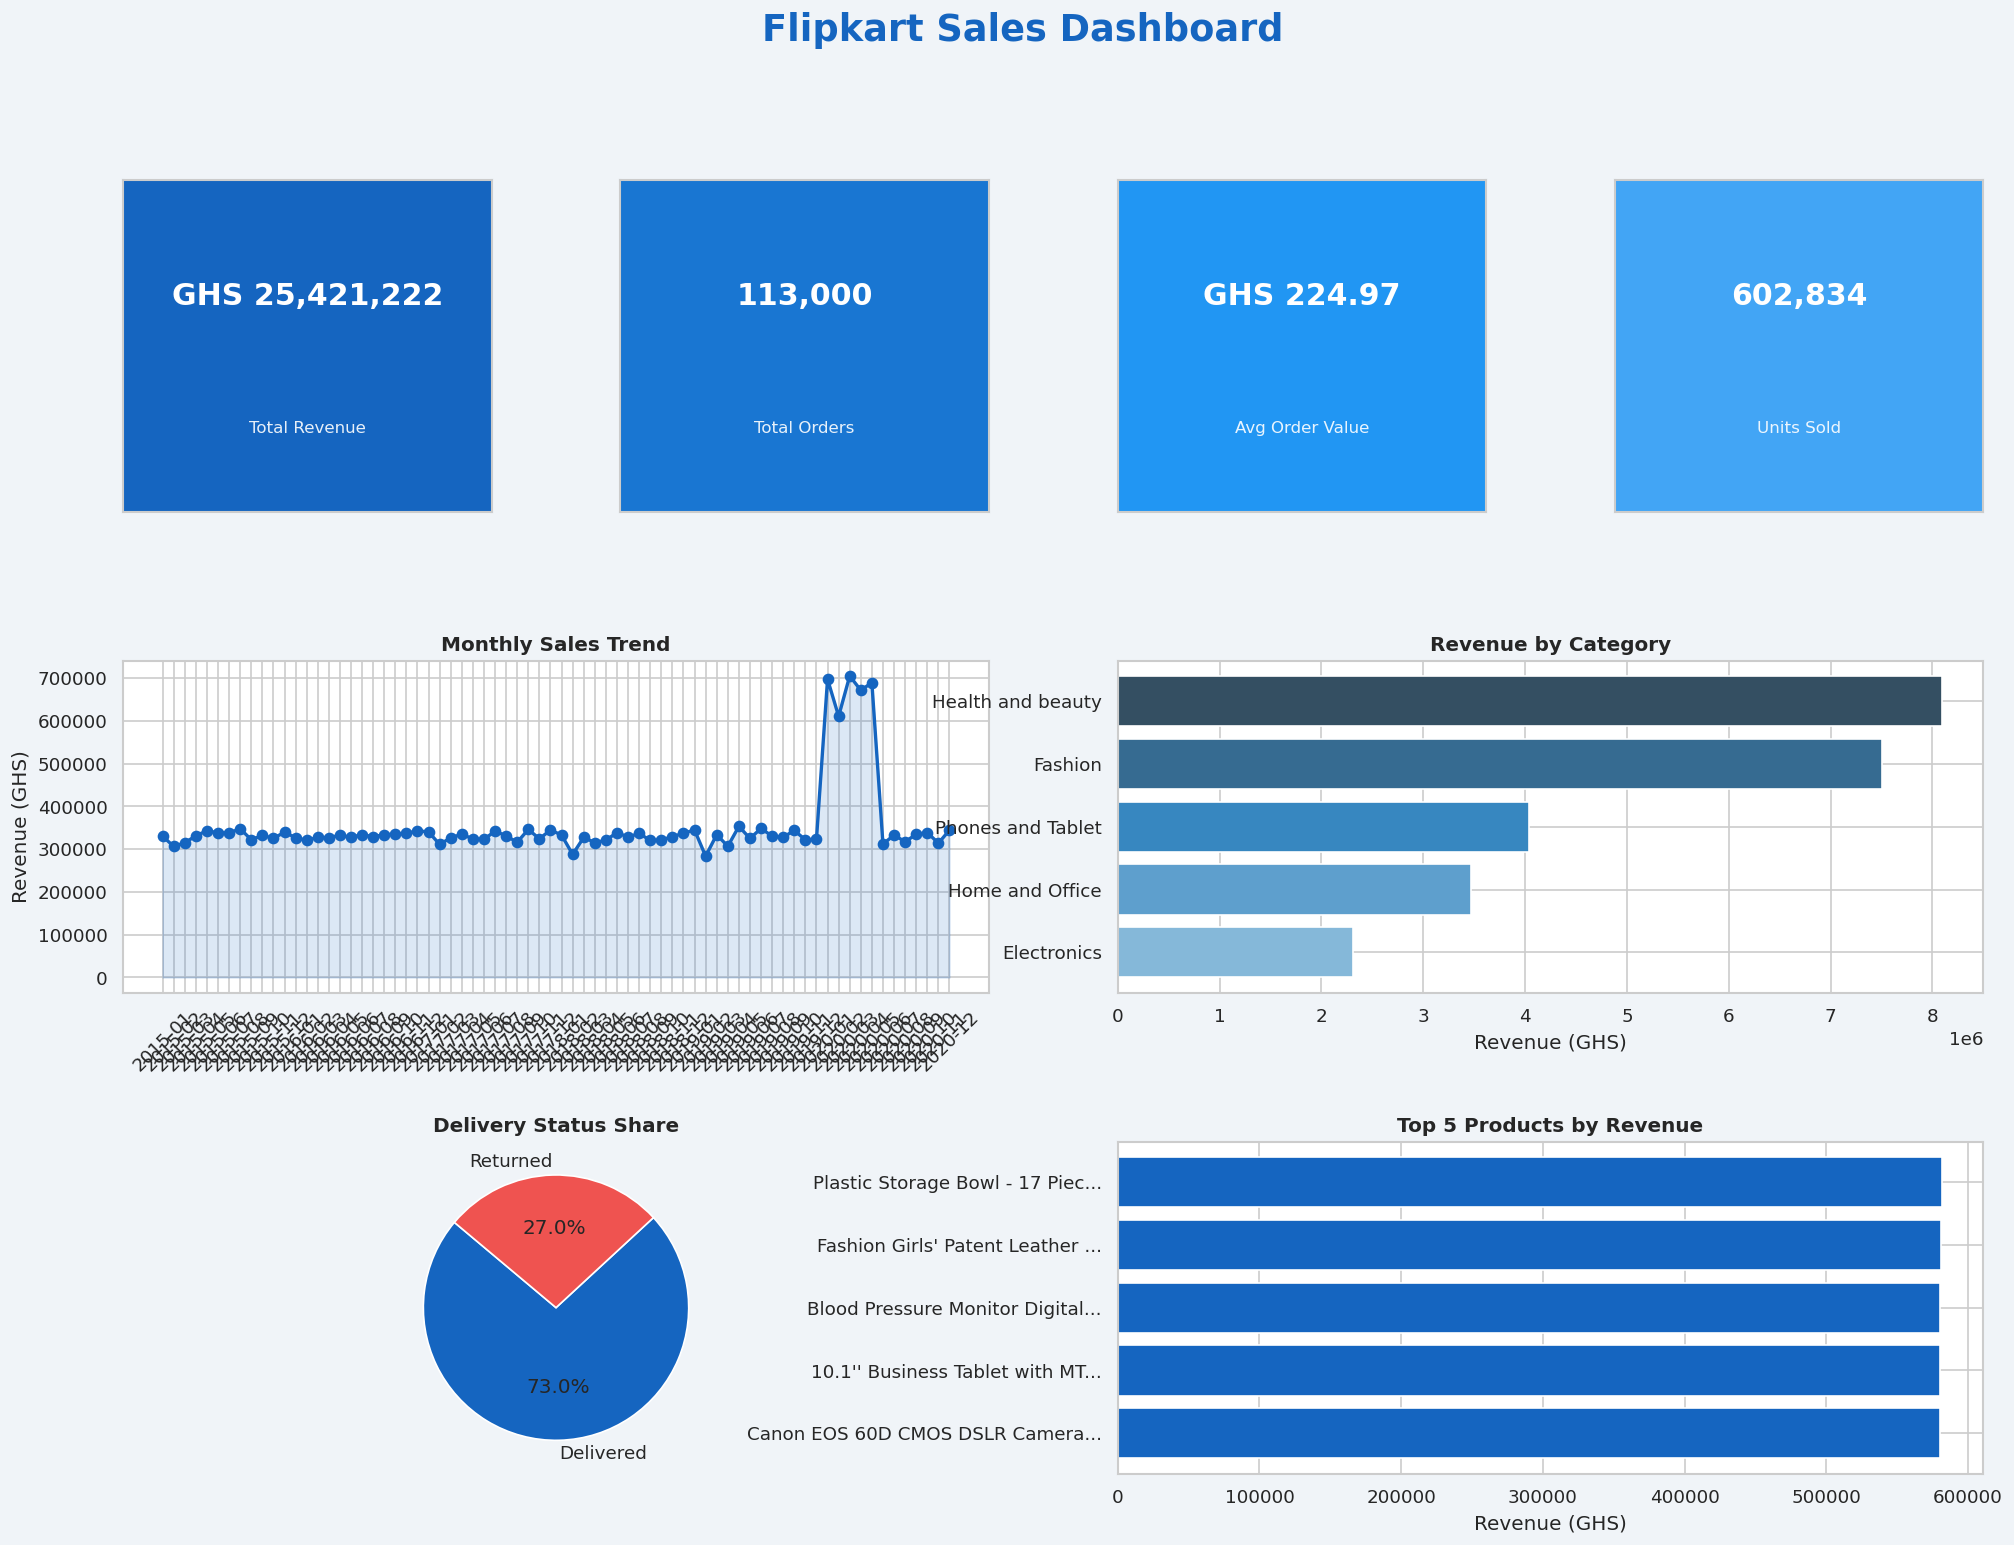

Dashboard saved to outputs/dashboard/dashboard_mockup.png


In [44]:
# ──  Dashboard Mockup ──
total_revenue = df['Sale Price'].sum()
total_orders  = df['OrderID'].nunique()
avg_order     = total_revenue / total_orders
total_units   = df['Order Quantity'].sum()
revenue_cat   = df.groupby('Product Category')['Sale Price'].sum().sort_values(ascending=False)
monthly_rev   = df.groupby('Month')['Sale Price'].sum()
monthly_rev.index = monthly_rev.index.astype(str)
status_share  = df['Status'].value_counts()
top_products  = df.groupby('Product')['Sale Price'].sum().nlargest(5)

fig = plt.figure(figsize=(20, 14), facecolor='#F0F4F8')
fig.suptitle('Flipkart Sales Dashboard', fontsize=22, fontweight='bold',
             color='#1565C0', y=0.98)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── KPI Cards (Row 1) ──
kpi_data = [
    ('Total Revenue', f'GHS {total_revenue:,.0f}', '#1565C0'),
    ('Total Orders',  f'{total_orders:,}',          '#1976D2'),
    ('Avg Order Value',f'GHS {avg_order:,.2f}',    '#2196F3'),
    ('Units Sold',    f'{total_units:,}',           '#42A5F5'),
]
for i, (label, value, color) in enumerate(kpi_data):
    ax_kpi = fig.add_subplot(gs[0, i])
    ax_kpi.set_facecolor(color)
    ax_kpi.text(0.5, 0.65, value, ha='center', va='center',
               fontsize=18, fontweight='bold', color='white',
               transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.25, label, ha='center', va='center',
               fontsize=10, color='white', alpha=0.9,
               transform=ax_kpi.transAxes)
    ax_kpi.set_xticks([]); ax_kpi.set_yticks([])

# ── Monthly Revenue Trend (Row 2, Left) ──
ax_line = fig.add_subplot(gs[1, :2])
ax_line.plot(monthly_rev.index, monthly_rev.values,
             marker='o', color='#1565C0', linewidth=2)
ax_line.fill_between(monthly_rev.index, monthly_rev.values, alpha=0.15, color='#1565C0')
ax_line.set_title('Monthly Sales Trend', fontweight='bold')
ax_line.tick_params(axis='x', rotation=45)
ax_line.set_ylabel('Revenue (GHS)')

# ── Revenue by Category (Row 2, Right) ──
ax_bar = fig.add_subplot(gs[1, 2:])
ax_bar.barh(revenue_cat.index[::-1], revenue_cat.values[::-1],
            color=sns.color_palette('Blues_d', len(revenue_cat)))
ax_bar.set_title('Revenue by Category', fontweight='bold')
ax_bar.set_xlabel('Revenue (GHS)')

# ── Delivery Status Pie (Row 3, Left) ──
ax_pie = fig.add_subplot(gs[2, :2])
ax_pie.pie(status_share.values, labels=status_share.index,
           autopct='%1.1f%%', startangle=140,
           colors=['#1565C0','#EF5350','#FFA726'][:len(status_share)])
ax_pie.set_title('Delivery Status Share', fontweight='bold')

# ── Top 5 Products (Row 3, Right) ──
ax_top = fig.add_subplot(gs[2, 2:])
short_names = [p[:30]+'...' if len(p) > 30 else p for p in top_products.index]
ax_top.barh(short_names[::-1], top_products.values[::-1], color='#1565C0')
ax_top.set_title('Top 5 Products by Revenue', fontweight='bold')
ax_top.set_xlabel('Revenue (GHS)')

plt.savefig('../outputs/dashboard/dashboard_mockup.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved to outputs/dashboard/dashboard_mockup.png')


## Dashboard Summary

The Flipkart Sales Dashboard provides a comprehensive overview of business performance across revenue, orders, customer behavior, and product categories.

### Key Performance Indicators (KPIs)

- **Total Revenue:** GHS 25.42 Million
- **Total Orders:** 113,000
- **Average Order Value:** GHS 224.97
- **Total Units Sold:** 602,834

### Key Findings

#### 1. Revenue Performance
The business generated over **GHS 25.42 million** in revenue from **113,000 orders**, demonstrating strong overall sales performance. The average customer spends approximately **GHS 224.97 per order**.

#### 2. Monthly Sales Trend
Revenue remained relatively stable throughout most months, averaging between **GHS 300,000 and GHS 350,000**. A significant spike occurred in early **2020**, where monthly revenue exceeded **GHS 700,000**, suggesting the impact of successful promotions, seasonal demand, or other business events.

#### 3. Product Category Performance
**Health and Beauty** is the highest revenue-generating category, followed by **Fashion**. Together, these categories contribute the majority of total sales revenue and represent the business's strongest market segments.

#### 4. Delivery Performance
Approximately **73% of orders were successfully delivered**, while **27% were returned**. Although delivery success remains high, the return rate indicates opportunities for improving product quality, customer expectations, and order fulfillment processes.

#### 5. Top Revenue-Generating Products
The highest-performing products contribute nearly equal levels of revenue, indicating that sales are distributed across multiple products rather than relying on a single bestseller.

### Business Recommendations

- Increase marketing investment in **Health and Beauty** and **Fashion** categories.
- Analyze the factors behind the **2020 sales spike** and replicate successful strategies.
- Investigate return causes to reduce the **27% return rate**.
- Maintain sufficient inventory for top-performing products.
- Focus customer retention and promotional campaigns on high-value customer segments.

### Conclusion

The dashboard reveals a healthy and growing business with strong revenue generation, diversified product performance, and consistent customer demand. Future growth can be achieved by strengthening top-performing categories, reducing returns, and leveraging insights from peak sales periods.